## Load signal NanoAOD files
Read Run 3 signal files (TT_StoAA_1lep, MT=1000, MS0=100, 13.6 TeV, 20k events) from EOS and load gen+reco branches.

In [33]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import glob
plt.rcParams['font.size'] = 13

eosdir = "/eos/uscms/store/user/abachary/TTtoSStt/Y2023/TT_StoAA_1lep/TT_StoAA_1lep/PrivateMC"
# find the timestamp directory automatically
import os
ts_dirs = sorted(os.listdir(eosdir))
eosdir = os.path.join(eosdir, ts_dirs[-1], "0000")
files = sorted(glob.glob(eosdir + "/*.root"))
print(f'{len(files)} files')

gen_branches = [
    'GenPart_pt', 'GenPart_eta', 'GenPart_phi', 'GenPart_mass',
    'GenPart_pdgId', 'GenPart_genPartIdxMother', 'GenPart_status',
    'GenPart_statusFlags',
]

reco_branches = [
    'Electron_pt', 'Electron_eta', 'Electron_phi', 'Electron_mass',
    'Electron_cutBased', 'Electron_mvaIso_WP80',
    'Electron_deltaEtaSC', 'Electron_dz', 'Electron_ip3d',
    'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass',
    'Muon_tightId', 'Muon_dz', 'Muon_dxy',
    'Jet_pt', 'Jet_eta', 'Jet_phi', 'Jet_mass',
    'Jet_btagDeepFlavB', 'Jet_jetId',
    'MET_pt', 'MET_phi',
    'Photon_pt', 'Photon_eta', 'Photon_phi',     'Photon_cutBased', 'Photon_pixelSeed',
]

events = uproot.concatenate({f: 'Events' for f in files}, gen_branches + reco_branches, library='ak')
print(f'{len(events)} events loaded')

20 files
20000 events loaded


## S0 daughter identification
Find all daughters of S0 (pdgId 6100001) using mother-index matching. Check species and multiplicity.

In [34]:
gp = ak.zip({
    'pt': events['GenPart_pt'],
    'eta': events['GenPart_eta'],
    'phi': events['GenPart_phi'],
    'mass': events['GenPart_mass'],
    'pdgId': events['GenPart_pdgId'],
    'motherId': events['GenPart_genPartIdxMother'],
    'status': events['GenPart_status'],
    'statusFlags': events['GenPart_statusFlags'],
})

pdgId = gp.pdgId
mother = gp.motherId

valid = (mother >= 0) & (mother < ak.num(pdgId))
safe_mother = ak.where(valid, mother, 0)
mother_pdg = ak.where(valid, pdgId[safe_mother], 0)

all_S0_daughters = gp[abs(mother_pdg) == 6100001]
real_daughters = all_S0_daughters[abs(all_S0_daughters.pdgId) != 6100001]
n_real = ak.num(real_daughters)

from collections import Counter
flat = ak.to_numpy(ak.flatten(abs(real_daughters.pdgId)))
names = {22:'photon', 24:'W', 23:'Z', 5:'b', 11:'e', 13:'mu', 15:'tau',
         12:'nu_e', 14:'nu_mu', 16:'nu_tau', 1:'d', 2:'u', 3:'s', 4:'c', 21:'gluon'}

print(f'Total events: {len(events)}')
print(f'Real S0 daughters per event: {ak.mean(n_real):.2f}')
print(f'Events with 2 daughters: {ak.sum(n_real == 2)}')
print(f'Events with 4 daughters: {ak.sum(n_real == 4)}')
print(f'Events with >4 daughters: {ak.sum(n_real > 4)}')
print(f'\nAll unique S0 daughter pdgIds: {set(flat)}')
print(f'\nS0 daughter species:')
for pdg, n in Counter(flat).most_common():
    print(f'  |pdgId|={pdg} ({names.get(pdg,"unknown")}): {n} ({n/len(flat)*100:.1f}%)')

Total events: 20000
Real S0 daughters per event: 4.00
Events with 2 daughters: 0
Events with 4 daughters: 20000
Events with >4 daughters: 0

All unique S0 daughter pdgIds: {22, 23}

S0 daughter species:
  |pdgId|=22 (photon): 78972 (98.7%)
  |pdgId|=23 (Z): 1028 (1.3%)


## Z boson daughters from S0 decay
Identify Z bosons in the S0 decay chain and their subsequent decay products. Check MET contribution from neutrinos.

In [35]:
# Z daughters from S0 decay chain
Z_from_S0 = real_daughters[abs(real_daughters.pdgId) == 23]
print(f'Z bosons from S0: {ak.sum(ak.num(Z_from_S0))}')
print(f'Events with Z from S0: {ak.sum(ak.num(Z_from_S0) > 0)}')

# find Z daughters
Z_daughters = gp[abs(mother_pdg) == 23]
Z_daughter_flat = ak.to_numpy(ak.flatten(abs(Z_daughters.pdgId)))
print(f'\nZ daughter species:')
for pdg, n in Counter(Z_daughter_flat).most_common(10):
    print(f'  |pdgId|={pdg} ({names.get(pdg,"unknown")}): {n}')

# now the big question: is MET clean?
print(f'\nMET: mean={ak.mean(events["MET_pt"]):.1f} GeV')


Z bosons from S0: 1028
Events with Z from S0: 1028

Z daughter species:
  |pdgId|=1 (d): 328
  |pdgId|=3 (s): 314
  |pdgId|=5 (b): 310
  |pdgId|=4 (c): 252
  |pdgId|=2 (u): 248
  |pdgId|=12 (nu_e): 142
  |pdgId|=16 (nu_tau): 134
  |pdgId|=14 (nu_mu): 126
  |pdgId|=11 (e): 76
  |pdgId|=15 (tau): 64

MET: mean=191.6 GeV


## MET check
Quick MET sanity check with the sxsx sample (both S0 decay to gauge bosons).

In [36]:
print(f'MET: mean={ak.mean(events["MET_pt"]):.1f} GeV')

MET: mean=191.6 GeV


## Helper functions
dR, four-momentum components, and invariant mass from (pt, eta, phi, mass).

In [37]:
def dR_calc(eta1, phi1, eta2, phi2):
    dphi = np.arctan2(np.sin(phi1 - phi2), np.cos(phi1 - phi2))
    return np.sqrt((eta1 - eta2)**2 + dphi**2)

def px(obj): return obj.pt * np.cos(obj.phi)
def py(obj): return obj.pt * np.sin(obj.phi)
def pz(obj): return obj.pt * np.sinh(obj.eta)
def energy(obj): return np.sqrt(px(obj)**2 + py(obj)**2 + pz(obj)**2 + obj.mass**2)

def inv_mass(*objs):
    tot_px = sum(px(o) for o in objs)
    tot_py = sum(py(o) for o in objs)
    tot_pz = sum(pz(o) for o in objs)
    tot_E = sum(energy(o) for o in objs)
    return np.sqrt(np.maximum(tot_E**2 - tot_px**2 - tot_py**2 - tot_pz**2, 0))

## Gen-level decay chain particle counting
Using isHardProcess flag, count T, tops, S0, photons, W, b, leptons, neutrinos, and light quarks per event to verify the expected 1-lepton topology.

In [38]:
isLastCopy = (gp.statusFlags & (1 << 13)) != 0
isHardProcess = (gp.statusFlags & (1 << 7)) != 0
gp_hp = gp[isHardProcess]

def get_mother_pdgId(particles, all_particles):
    idx = particles.motherId
    valid = (idx >= 0) & (idx < ak.num(all_particles))
    safe = ak.where(valid, idx, 0)
    return ak.where(valid, all_particles.pdgId[safe], 0)

gen_T = gp_hp[abs(gp_hp.pdgId) == 6000006]

gen_tops = gp_hp[abs(gp_hp.pdgId) == 6]
mom_tops = get_mother_pdgId(gen_tops, gp)
tops_from_T = gen_tops[abs(mom_tops) == 6000006]

gen_S0 = gp_hp[abs(gp_hp.pdgId) == 6100001]
mom_S0 = get_mother_pdgId(gen_S0, gp)
S0_from_T = gen_S0[abs(mom_S0) == 6000006]

gen_pho = gp_hp[abs(gp_hp.pdgId) == 22]
mom_pho = get_mother_pdgId(gen_pho, gp)
pho_from_S0 = gen_pho[abs(mom_pho) == 6100001]

gen_W = gp_hp[abs(gp_hp.pdgId) == 24]
mom_W = get_mother_pdgId(gen_W, gp)
W_from_top = gen_W[abs(mom_W) == 6]

gen_b = gp_hp[abs(gp_hp.pdgId) == 5]
mom_b = get_mother_pdgId(gen_b, gp)
b_from_top = gen_b[abs(mom_b) == 6]

gen_lep = gp_hp[(abs(gp_hp.pdgId) == 11) | (abs(gp_hp.pdgId) == 13)]
mom_lep = get_mother_pdgId(gen_lep, gp)
lep_from_W = gen_lep[abs(mom_lep) == 24]

gen_nu = gp_hp[(abs(gp_hp.pdgId) == 12) | (abs(gp_hp.pdgId) == 14)]
mom_nu = get_mother_pdgId(gen_nu, gp)
nu_from_W = gen_nu[abs(mom_nu) == 24]

gen_q = gp_hp[(abs(gp_hp.pdgId) <= 4)]
mom_q = get_mother_pdgId(gen_q, gp)
q_from_W = gen_q[abs(mom_q) == 24]

print(f'T per event: {ak.mean(ak.num(gen_T)):.2f}')
print(f'tops from T: {ak.mean(ak.num(tops_from_T)):.2f}')
print(f'S0 from T: {ak.mean(ak.num(S0_from_T)):.2f}')
print(f'photons from S0: {ak.mean(ak.num(pho_from_S0)):.2f}')
print(f'W from top: {ak.mean(ak.num(W_from_top)):.2f}')
print(f'b from top: {ak.mean(ak.num(b_from_top)):.2f}')
print(f'leptons from W: {ak.mean(ak.num(lep_from_W)):.2f}')
print(f'neutrinos from W: {ak.mean(ak.num(nu_from_W)):.2f}')
print(f'light quarks from W: {ak.mean(ak.num(q_from_W)):.2f}')

T per event: 2.00
tops from T: 2.00
S0 from T: 2.00
photons from S0: 3.95
W from top: 1.98
b from top: 2.00
leptons from W: 0.99
neutrinos from W: 0.99
light quarks from W: 1.98


## Gen-level event selection
Require exactly 1 lepton from W, 1 neutrino, 2 b-quarks from top, and >=2 photons from S0. Assign leptonic vs hadronic b using dR to the lepton.

In [39]:
n_lep_gen = ak.num(lep_from_W)
n_nu_gen = ak.num(nu_from_W)
n_b_gen = ak.num(b_from_top)
n_pho_gen = ak.num(pho_from_S0)

gen_sel = (n_lep_gen == 1) & (n_nu_gen == 1) & (n_b_gen == 2) & (n_pho_gen >= 2)

print(f'Total events: {len(events)}')
print(f'  == 1 lepton from W: {ak.sum(n_lep_gen == 1)}')
print(f'  == 1 neutrino from W: {ak.sum(n_nu_gen == 1)}')
print(f'  == 2 b from top: {ak.sum(n_b_gen == 2)}')
print(f'  >= 2 photons from S0: {ak.sum(n_pho_gen >= 2)}')
print(f'  All cuts: {ak.sum(gen_sel)}')

lep_s = lep_from_W[gen_sel][:, 0]
nu_s = nu_from_W[gen_sel][:, 0]
b_s = b_from_top[gen_sel]
pho_s = pho_from_S0[gen_sel]

dR_b_lep = dR_calc(b_s.eta, b_s.phi, lep_s.eta, lep_s.phi)
lep_b_idx = ak.argmin(dR_b_lep, axis=1, keepdims=True)
had_b_idx = ak.argmax(dR_b_lep, axis=1, keepdims=True)
b_lep = b_s[lep_b_idx][:, 0]
b_had = b_s[had_b_idx][:, 0]

print(f'dR(lepton, leptonic b) mean: {ak.mean(dR_calc(b_lep.eta, b_lep.phi, lep_s.eta, lep_s.phi)):.2f}')
print(f'dR(lepton, hadronic b) mean: {ak.mean(dR_calc(b_had.eta, b_had.phi, lep_s.eta, lep_s.phi)):.2f}')

Total events: 20000
  == 1 lepton from W: 19805
  == 1 neutrino from W: 19805
  == 2 b from top: 20000
  >= 2 photons from S0: 20000
  All cuts: 19805
dR(lepton, leptonic b) mean: 0.95
dR(lepton, hadronic b) mean: 2.37


## Gen-level mass reconstruction
Reconstruct W, top, S0, and T masses at gen level using the first two photons (assumed from same S0). This is the ground truth check.

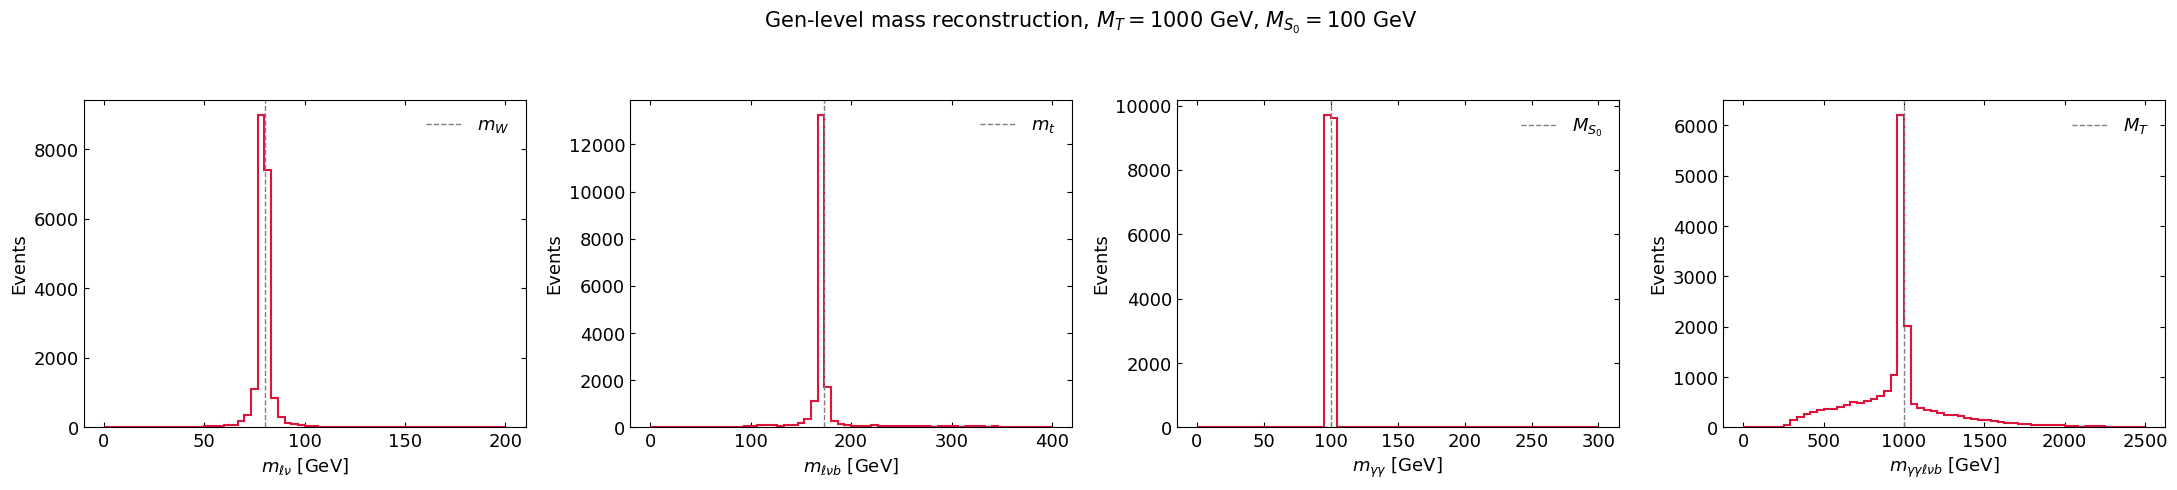

In [40]:
g1 = pho_s[:, 0]
g2 = pho_s[:, 1]

m_W_gen = inv_mass(lep_s, nu_s)
m_top_gen = inv_mass(lep_s, nu_s, b_lep)
m_S0_gen = inv_mass(g1, g2)
m_T_gen = inv_mass(lep_s, nu_s, b_lep, g1, g2)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(r'Gen-level mass reconstruction, $M_T = 1000$ GeV, $M_{S_0} = 100$ GeV', fontsize=15)

axes[0].hist(ak.to_numpy(m_W_gen), bins=60, range=(0, 200),
    histtype='step', color='crimson', linewidth=1.5)
axes[0].axvline(80.4, color='gray', linestyle='--', linewidth=1, label=r'$m_W$')
axes[0].set_xlabel(r'$m_{\ell\nu}$ [GeV]')
axes[0].set_ylabel('Events')
axes[0].legend(frameon=False)

axes[1].hist(ak.to_numpy(m_top_gen), bins=60, range=(0, 400),
    histtype='step', color='crimson', linewidth=1.5)
axes[1].axvline(173, color='gray', linestyle='--', linewidth=1, label=r'$m_t$')
axes[1].set_xlabel(r'$m_{\ell\nu b}$ [GeV]')
axes[1].set_ylabel('Events')
axes[1].legend(frameon=False)

axes[2].hist(ak.to_numpy(m_S0_gen), bins=60, range=(0, 300),
    histtype='step', color='crimson', linewidth=1.5)
axes[2].axvline(100, color='gray', linestyle='--', linewidth=1, label=r'$M_{S_0}$')
axes[2].set_xlabel(r'$m_{\gamma\gamma}$ [GeV]')
axes[2].set_ylabel('Events')
axes[2].legend(frameon=False)

axes[3].hist(ak.to_numpy(m_T_gen), bins=60, range=(0, 2500),
    histtype='step', color='crimson', linewidth=1.5)
axes[3].axvline(1000, color='gray', linestyle='--', linewidth=1, label=r'$M_T$')
axes[3].set_xlabel(r'$m_{\gamma\gamma\ell\nu b}$ [GeV]')
axes[3].set_ylabel('Events')
axes[3].legend(frameon=False)

for a in axes:
    a.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('gen_mass_reco_1000_100_sxsx.pdf', bbox_inches='tight')
plt.show()

## Gen photon pairing check
For events with 4 gen photons from S0, test which pair combination reconstructs closest to MS0=100 GeV. Confirms photons 0,1 are always from the same S0.

In [41]:
# mgg for first two photons vs all combinations
m_12 = inv_mass(pho_s[:, 0], pho_s[:, 1])
has_4 = ak.num(pho_s) >= 4

# events with 4 photons: try both pairings
pho4 = pho_s[has_4]
m_pair1 = inv_mass(pho4[:, 0], pho4[:, 1])  # 0+1 vs 2+3
m_pair2 = inv_mass(pho4[:, 0], pho4[:, 2])  # 0+2 vs 1+3
m_pair3 = inv_mass(pho4[:, 0], pho4[:, 3])  # 0+3 vs 1+2

print(f'Events with 4 photons: {ak.sum(has_4)}')
print(f'Pair (0,1) near 100 GeV: {ak.sum(abs(m_pair1 - 100) < 10)}')
print(f'Pair (0,2) near 100 GeV: {ak.sum(abs(m_pair2 - 100) < 10)}')
print(f'Pair (0,3) near 100 GeV: {ak.sum(abs(m_pair3 - 100) < 10)}')

Events with 4 photons: 18786
Pair (0,1) near 100 GeV: 18786
Pair (0,2) near 100 GeV: 677
Pair (0,3) near 100 GeV: 623


## Which S0 photon pair belongs to the leptonic top?
Use dR(photon pair, lepton) to assign photon pairs to the leptonic vs hadronic T. Compare m_T using the closer vs farther pair.

Pair (0,1) closer to lepton: 9447 (50.3%)
Pair (2,3) closer to lepton: 9339 (49.7%)


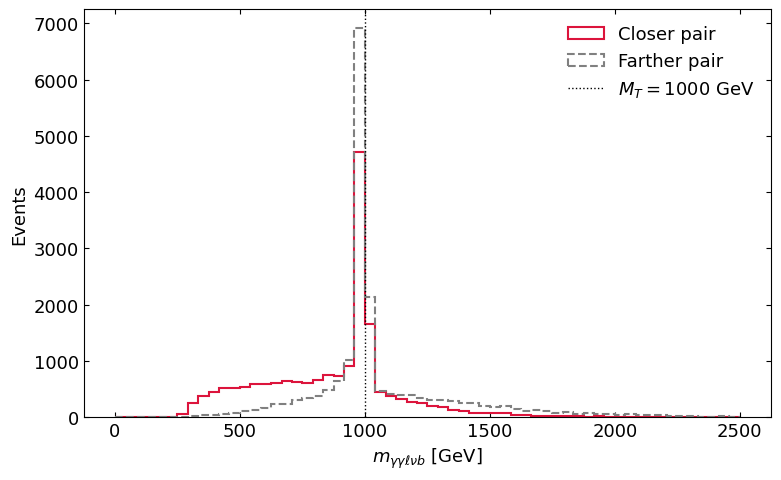

Closer pair m_T mean: 876 GeV
Farther pair m_T mean: 1078 GeV


In [42]:
# which S0's photons are closer to the leptonic top?
# use dR between photon pair and lepton as proxy

dR_g1_lep = dR_calc(pho_s[:, 0].eta, pho_s[:, 0].phi, lep_s.eta, lep_s.phi)

has4 = ak.num(pho_s) >= 4
dR_pair1_lep = dR_calc(pho_s[has4][:, 0].eta, pho_s[has4][:, 0].phi, lep_s[has4].eta, lep_s[has4].phi)
dR_pair2_lep = dR_calc(pho_s[has4][:, 2].eta, pho_s[has4][:, 2].phi, lep_s[has4].eta, lep_s[has4].phi)

pair1_closer = dR_pair1_lep < dR_pair2_lep
print(f'Pair (0,1) closer to lepton: {ak.sum(pair1_closer)} ({ak.mean(pair1_closer):.1%})')
print(f'Pair (2,3) closer to lepton: {ak.sum(~pair1_closer)} ({ak.mean(~pair1_closer):.1%})')

# T mass using the correct pair (closer to lepton)
g1_correct = ak.where(pair1_closer, pho_s[has4][:, 0], pho_s[has4][:, 2])
g2_correct = ak.where(pair1_closer, pho_s[has4][:, 1], pho_s[has4][:, 3])
g1_wrong = ak.where(pair1_closer, pho_s[has4][:, 2], pho_s[has4][:, 0])
g2_wrong = ak.where(pair1_closer, pho_s[has4][:, 3], pho_s[has4][:, 1])

m_T_correct = inv_mass(lep_s[has4], nu_s[has4], b_lep[has4], g1_correct, g2_correct)
m_T_wrong = inv_mass(lep_s[has4], nu_s[has4], b_lep[has4], g1_wrong, g2_wrong)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ak.to_numpy(m_T_correct), bins=60, range=(0, 2500),
    histtype='step', color='crimson', linewidth=1.5, label='Closer pair')
ax.hist(ak.to_numpy(m_T_wrong), bins=60, range=(0, 2500),
    histtype='step', color='gray', linewidth=1.5, linestyle='--', label='Farther pair')
ax.axvline(1000, color='black', linestyle=':', linewidth=1, label=r'$M_T = 1000$ GeV')
ax.set_xlabel(r'$m_{\gamma\gamma\ell\nu b}$ [GeV]')
ax.set_ylabel('Events')
ax.legend(frameon=False)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

print(f'Closer pair m_T mean: {ak.mean(m_T_correct):.0f} GeV')
print(f'Farther pair m_T mean: {ak.mean(m_T_wrong):.0f} GeV')

## Leptonic T mass with correctly assigned photon pair
Reconstruct leptonic T mass using the photon pair from the S0 that is farther from the lepton (correct assignment: the leptonic T's S0 photons combine with its own top decay products).

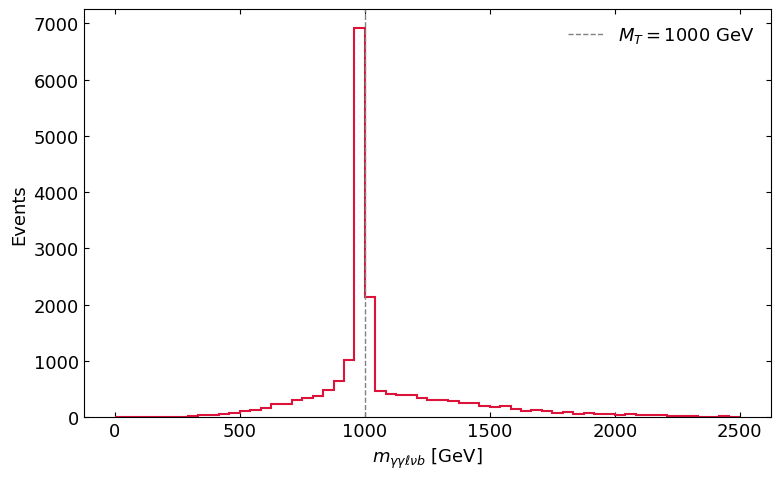

m_T mean: 1078 GeV


In [43]:
g1_lep = ak.where(pair1_closer, pho_s[has4][:, 2], pho_s[has4][:, 0])
g2_lep = ak.where(pair1_closer, pho_s[has4][:, 3], pho_s[has4][:, 1])

m_T_fixed = inv_mass(lep_s[has4], nu_s[has4], b_lep[has4], g1_lep, g2_lep)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ak.to_numpy(m_T_fixed), bins=60, range=(0, 2500),
    histtype='step', color='crimson', linewidth=1.5)
ax.axvline(1000, color='gray', linestyle='--', linewidth=1, label=r'$M_T = 1000$ GeV')
ax.set_xlabel(r'$m_{\gamma\gamma\ell\nu b}$ [GeV]')
ax.set_ylabel('Events')
ax.legend(frameon=False)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

print(f'm_T mean: {ak.mean(m_T_fixed):.0f} GeV')

## Verify photon-to-S0 mother assignment
Confirm using gen mother indices that photons 0,1 always share the same S0 mother (100% in 16992 events with 4 photons).

In [44]:
# find which S0 each photon comes from using mother index
pho_hp = gp_hp[abs(gp_hp.pdgId) == 22]
pho_mother_idx = pho_hp.motherId

# for gen-selected events with 4+ photons from S0
pho_sel = pho_from_S0[gen_sel]
has4 = ak.num(pho_sel) >= 4

# use the mother index to group photons by S0
pho4 = pho_from_S0[gen_sel][has4]
pho4_motherIdx = gp_hp[abs(gp_hp.pdgId) == 22][abs(get_mother_pdgId(gp_hp[abs(gp_hp.pdgId) == 22], gp)) == 6100001][gen_sel][has4].motherId

# first two photons share one S0 mother, last two share another
# check: do photons 0 and 1 have the same mother?
same_mother_01 = pho4_motherIdx[:, 0] == pho4_motherIdx[:, 1]
print(f'Photons 0,1 share same S0 mother: {ak.sum(same_mother_01)} ({ak.mean(same_mother_01):.1%})')

Photons 0,1 share same S0 mother: 18786 (100.0%)


## S0-to-T mother assignment
Trace which T produced each S0 using mother indices. Verify that the two S0 always come from different T quarks.

Pair (0,1) is leptonic-side S0: 9424 (50.2%)
Pair (2,3) is leptonic-side S0: 9362 (49.8%)


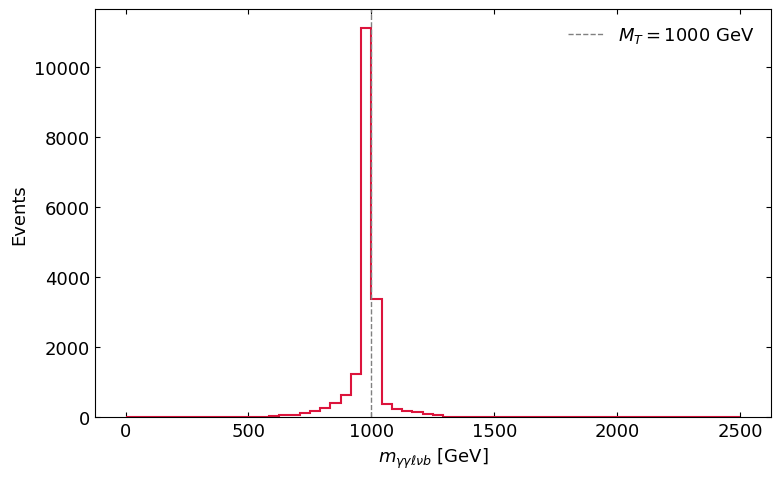

m_T mean: 983 GeV


In [45]:
# find which T each S0 comes from
S0_sel = S0_from_T[gen_sel][has4]
S0_motherIdx = gp_hp[abs(gp_hp.pdgId) == 6100001][abs(get_mother_pdgId(gp_hp[abs(gp_hp.pdgId) == 6100001], gp)) == 6000006][gen_sel][has4].motherId

# find which T the leptonic top comes from
top_sel = tops_from_T[gen_sel][has4]
top_motherIdx = gp_hp[abs(gp_hp.pdgId) == 6][abs(get_mother_pdgId(gp_hp[abs(gp_hp.pdgId) == 6], gp)) == 6000006][gen_sel][has4].motherId

# the leptonic top is the one whose W decays leptonically
# we already know lep_from_W exists, so find which top is the leptonic one
# match: S0 mother index == leptonic top mother index means same T

# S0 that shares T with the leptonic top
# photon mother (S0) -> S0 mother (T) should match top mother (T)
pho_S0_motherIdx = pho4_motherIdx[:, 0]  # S0 index for photons 0,1
pho_S0_T_motherIdx = gp.pdgId  # need the T index

# simpler approach: check if photons 0,1 give m_T closer to 1000
m_T_pair01 = inv_mass(lep_s[has4], nu_s[has4], b_lep[has4], pho4[:, 0], pho4[:, 1])
m_T_pair23 = inv_mass(lep_s[has4], nu_s[has4], b_lep[has4], pho4[:, 2], pho4[:, 3])

pair01_is_lep = abs(m_T_pair01 - 1000) < abs(m_T_pair23 - 1000)

print(f'Pair (0,1) is leptonic-side S0: {ak.sum(pair01_is_lep)} ({ak.mean(pair01_is_lep):.1%})')
print(f'Pair (2,3) is leptonic-side S0: {ak.sum(~pair01_is_lep)} ({ak.mean(~pair01_is_lep):.1%})')

# use correct assignment
g1_lep = ak.where(pair01_is_lep, pho4[:, 0], pho4[:, 2])
g2_lep = ak.where(pair01_is_lep, pho4[:, 1], pho4[:, 3])

m_T_gen_correct = inv_mass(lep_s[has4], nu_s[has4], b_lep[has4], g1_lep, g2_lep)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ak.to_numpy(m_T_gen_correct), bins=60, range=(0, 2500),
    histtype='step', color='crimson', linewidth=1.5)
ax.axvline(1000, color='gray', linestyle='--', linewidth=1, label=r'$M_T = 1000$ GeV')
ax.set_xlabel(r'$m_{\gamma\gamma\ell\nu b}$ [GeV]')
ax.set_ylabel('Events')
ax.legend(frameon=False)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

print(f'm_T mean: {ak.mean(m_T_gen_correct):.0f} GeV')

## Gen-level dR between photon pairs from same S0
Compute dR between the two photons from each S0. This tells us whether the photons are resolved or merged at detector level. At MT=1000, MS0=100, the S0 is boosted and photons can be collimated.

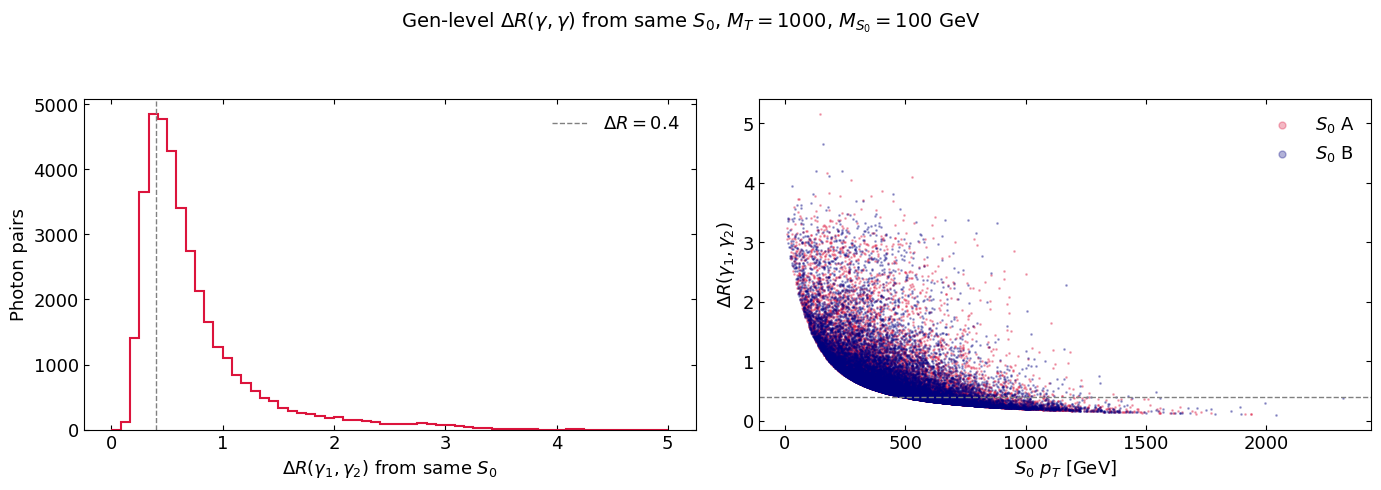

Gen dR(gamma,gamma) same S0:
  mean: 0.74
  median: 0.58
  fraction with dR < 0.4: 23.9%
  fraction with dR < 0.3: 9.3%


In [46]:
# gen-level dR between photons from the same S0
# photons 0,1 are from S0_A; photons 2,3 are from S0_B (confirmed above)
pho_gen = pho_from_S0[gen_sel]
has4_dr = ak.num(pho_gen) >= 4
pho4_dr = pho_gen[has4_dr]

dR_S0_A = dR_calc(pho4_dr[:, 0].eta, pho4_dr[:, 0].phi,
                  pho4_dr[:, 1].eta, pho4_dr[:, 1].phi)
dR_S0_B = dR_calc(pho4_dr[:, 2].eta, pho4_dr[:, 2].phi,
                  pho4_dr[:, 3].eta, pho4_dr[:, 3].phi)
dR_all_gen = ak.concatenate([dR_S0_A, dR_S0_B])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(r'Gen-level $\Delta R(\gamma,\gamma)$ from same $S_0$, $M_T=1000$, $M_{S_0}=100$ GeV', fontsize=14)

axes[0].hist(ak.to_numpy(dR_all_gen), bins=60, range=(0, 5),
    histtype='step', color='crimson', linewidth=1.5)
axes[0].axvline(0.4, color='gray', linestyle='--', linewidth=1, label=r'$\Delta R = 0.4$')
axes[0].set_xlabel(r'$\Delta R(\gamma_1, \gamma_2)$ from same $S_0$')
axes[0].set_ylabel('Photon pairs')
axes[0].legend(frameon=False)
axes[0].tick_params(direction='in', top=True, right=True)

# dR vs S0 pT
S0_gen = S0_from_T[gen_sel][has4_dr]
s0_pt_A = S0_gen[:, 0].pt
s0_pt_B = S0_gen[:, 1].pt
axes[1].scatter(ak.to_numpy(s0_pt_A), ak.to_numpy(dR_S0_A), s=1, alpha=0.3, color='crimson', label=r'$S_0$ A')
axes[1].scatter(ak.to_numpy(s0_pt_B), ak.to_numpy(dR_S0_B), s=1, alpha=0.3, color='navy', label=r'$S_0$ B')
axes[1].axhline(0.4, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel(r'$S_0$ $p_T$ [GeV]')
axes[1].set_ylabel(r'$\Delta R(\gamma_1, \gamma_2)$')
axes[1].legend(frameon=False, markerscale=5)
axes[1].tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('gen_dR_photons_1000_100.pdf', bbox_inches='tight')
plt.show()

merged = ak.to_numpy(dR_all_gen) < 0.4
print(f'Gen dR(gamma,gamma) same S0:')
print(f'  mean: {ak.mean(dR_all_gen):.2f}')
print(f'  median: {np.median(ak.to_numpy(dR_all_gen)):.2f}')
print(f'  fraction with dR < 0.4: {np.mean(merged):.1%}')
print(f'  fraction with dR < 0.3: {np.mean(ak.to_numpy(dR_all_gen) < 0.3):.1%}')


## Reco object selection
Build electrons, muons, jets, b-jets, and photons with standard CMS ID cuts. Jets are lepton-cleaned with dR > 0.4.

In [47]:
# reco object selection
# Run 3: use DeepJet (btagDeepFlavB) medium WP for 2023
DEEPJET_MED = 0.2431

ele = ak.zip({'pt': events['Electron_pt'], 'eta': events['Electron_eta'],
    'phi': events['Electron_phi'], 'mass': events['Electron_mass'],
    'cutBased': events['Electron_cutBased'],
    'mvaWP80': events['Electron_mvaIso_WP80'],
    'dEtaSC': events['Electron_deltaEtaSC'], 'dz': events['Electron_dz'],
    'ip3d': events['Electron_ip3d']})

mu = ak.zip({'pt': events['Muon_pt'], 'eta': events['Muon_eta'],
    'phi': events['Muon_phi'], 'mass': events['Muon_mass'],
    'tightId': events['Muon_tightId'], 'dz': events['Muon_dz'],
    'dxy': events['Muon_dxy']})

jets_raw = ak.zip({'pt': events['Jet_pt'], 'eta': events['Jet_eta'],
    'phi': events['Jet_phi'], 'mass': events['Jet_mass'],
    'btag': events['Jet_btagDeepFlavB'], 'jetId': events['Jet_jetId']})

pho_reco = ak.zip({'pt': events['Photon_pt'], 'eta': events['Photon_eta'],
    'phi': events['Photon_phi'], 'mass': 0.0,
    'cutBased': events['Photon_cutBased'], 'pixelSeed': events['Photon_pixelSeed']})

met_r = events['MET_pt']
metphi_r = events['MET_phi']

# electron selection
sc_eta = abs(ele.eta + ele.dEtaSC)
barrel = sc_eta < 1.4442
endcap = sc_eta > 1.566
ele_sel = ele[(ele.pt > 30) & (abs(ele.eta) < 2.4) & (barrel | endcap) &
    (ele.cutBased >= 3) & (ele.mvaWP80) &
    ak.where(barrel, (abs(ele.dz) < 0.10) & (ele.ip3d < 0.05),
                      (abs(ele.dz) < 0.20) & (ele.ip3d < 0.10))]

# muon selection
mu_sel = mu[(mu.pt > 30) & (abs(mu.eta) < 2.4) & mu.tightId &
    (abs(mu.dz) < 0.05) & (abs(mu.dxy) < 0.02)]

# merge leptons, sort by pT
lep_reco = ak.concatenate([ele_sel, mu_sel], axis=1)
lep_reco = lep_reco[ak.argsort(lep_reco.pt, ascending=False)]

# jet selection + lepton overlap removal
jet_sel = jets_raw[(jets_raw.pt > 30) & (abs(jets_raw.eta) < 2.4) & (jets_raw.jetId >= 2)]
def remove_overlap(jets, leps, dR_cut=0.4):
    pair_dR = dR_calc(jets.eta[:, :, None], jets.phi[:, :, None],
                      leps.eta[:, None, :], leps.phi[:, None, :])
    min_dR = ak.min(pair_dR, axis=2)
    no_lep = ak.fill_none(min_dR, 999) > dR_cut
    return jets[no_lep]

jet_clean = remove_overlap(jet_sel, lep_reco)
bjet_reco = jet_clean[jet_clean.btag > DEEPJET_MED]

# photon selection
pho_sel = pho_reco[(pho_reco.pt > 20) & (abs(pho_reco.eta) < 2.5) &
    (pho_reco.cutBased >= 2) & (~pho_reco.pixelSeed)]

print(f'Electrons selected per event: {ak.mean(ak.num(ele_sel)):.2f}')
print(f'Muons selected per event: {ak.mean(ak.num(mu_sel)):.2f}')
print(f'Leptons per event: {ak.mean(ak.num(lep_reco)):.2f}')
print(f'Jets (cleaned) per event: {ak.mean(ak.num(jet_clean)):.2f}')
print(f'B-jets per event: {ak.mean(ak.num(bjet_reco)):.2f}')
print(f'Photons per event: {ak.mean(ak.num(pho_sel)):.2f}')
print(f'MET mean: {ak.mean(met_r):.1f} GeV')

Electrons selected per event: 0.23
Muons selected per event: 0.50
Leptons per event: 0.73
Jets (cleaned) per event: 4.28
B-jets per event: 1.43
Photons per event: 2.17
MET mean: 191.6 GeV


## Reco event selection
Require exactly 1 lepton, >=1 b-jet, >=2 photons. Print cutflow.

In [48]:
reco_sel = (ak.num(lep_reco) == 1) & (ak.num(bjet_reco) >= 1) & (ak.num(pho_sel) >= 2)

print(f'Reco selection: {ak.sum(reco_sel)} / {len(events)} ({ak.mean(reco_sel):.1%})')
print(f'  == 1 lepton: {ak.sum(ak.num(lep_reco) == 1)}')
print(f'  >= 1 b-jet: {ak.sum(ak.num(bjet_reco) >= 1)}')
print(f'  >= 2 photons: {ak.sum(ak.num(pho_sel) >= 2)}')

Reco selection: 7117 / 20000 (35.6%)
  == 1 lepton: 11209
  >= 1 b-jet: 17763
  >= 2 photons: 14404


## Reco-level dR between leading photon pair
Compute dR between the two highest-pT reco photons passing selection. Check what fraction are too close to resolve.

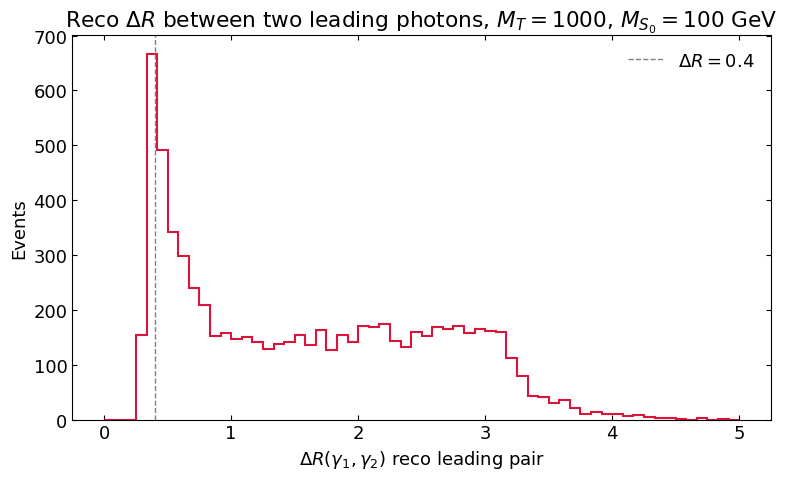

Reco dR(gamma1, gamma2) leading pair:
  mean: 1.60
  median: 1.50
  fraction with dR < 0.4: 9.5%
  fraction with dR < 0.3: 0.0%


In [49]:
# reco-level dR between leading two photons
pho_reco_sel = pho_sel[reco_sel]
has2_reco = ak.num(pho_reco_sel) >= 2
pho2 = pho_reco_sel[has2_reco]

dR_reco_leading = dR_calc(pho2[:, 0].eta, pho2[:, 0].phi,
                          pho2[:, 1].eta, pho2[:, 1].phi)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ak.to_numpy(dR_reco_leading), bins=60, range=(0, 5),
    histtype='step', color='crimson', linewidth=1.5)
ax.axvline(0.4, color='gray', linestyle='--', linewidth=1, label=r'$\Delta R = 0.4$')
ax.set_xlabel(r'$\Delta R(\gamma_1, \gamma_2)$ reco leading pair')
ax.set_ylabel('Events')
ax.set_title(r'Reco $\Delta R$ between two leading photons, $M_T=1000$, $M_{S_0}=100$ GeV')
ax.legend(frameon=False)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.savefig('reco_dR_photons_1000_100.pdf', bbox_inches='tight')
plt.show()

reco_merged = ak.to_numpy(dR_reco_leading) < 0.4
print(f'Reco dR(gamma1, gamma2) leading pair:')
print(f'  mean: {ak.mean(dR_reco_leading):.2f}')
print(f'  median: {np.median(ak.to_numpy(dR_reco_leading)):.2f}')
print(f'  fraction with dR < 0.4: {np.mean(reco_merged):.1%}')
print(f'  fraction with dR < 0.3: {np.mean(ak.to_numpy(dR_reco_leading) < 0.3):.1%}')


## Reco event-level variables
HT, ST, and mgg (leading photon pair) for signal after reco selection.

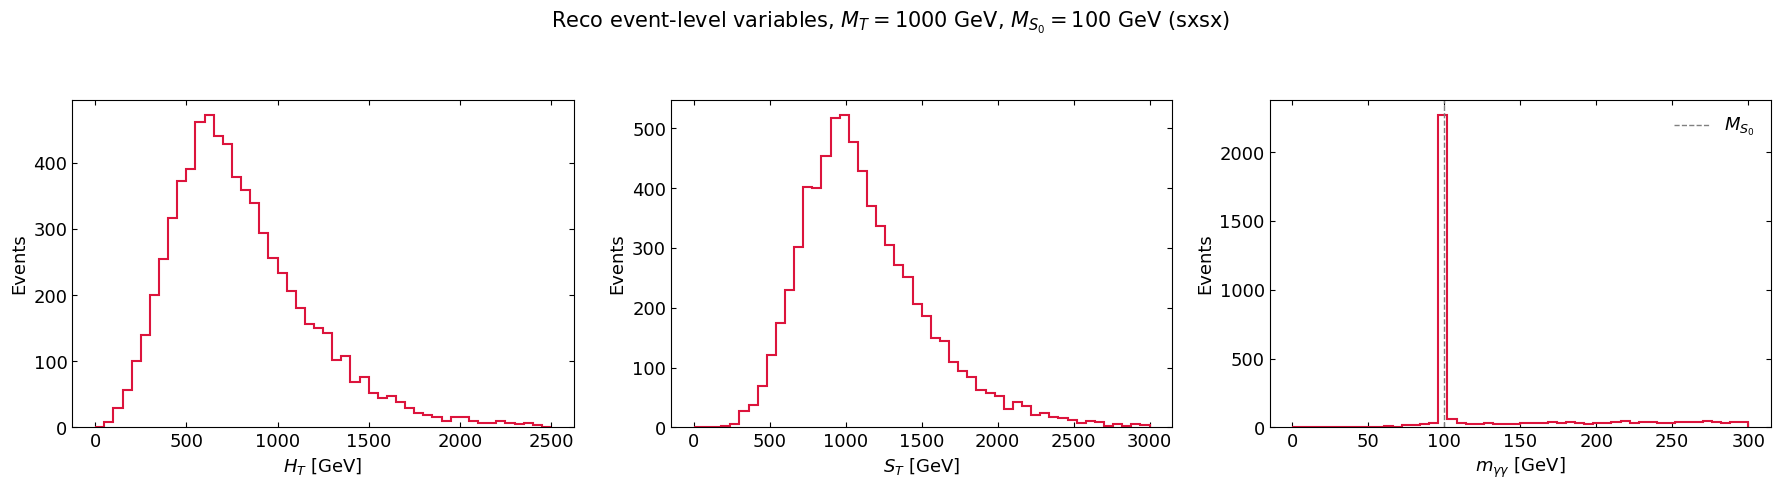

HT: mean=809, median=737 GeV
ST: mean=1135, median=1053 GeV
mgg: mean=395.3, median=302.5 GeV
MET: mean=183.9 GeV


In [50]:
jet_r = jet_clean[reco_sel]
lep_r = lep_reco[reco_sel][:, 0]
pho_r = pho_sel[reco_sel]
met_rsel = met_r[reco_sel]
metphi_rsel = metphi_r[reco_sel]
bjet_r = bjet_reco[reco_sel]

HT = ak.sum(jet_r.pt, axis=1)
ST = HT + lep_r.pt + met_rsel
mgg = inv_mass(pho_r[:, 0], pho_r[:, 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r'Reco event-level variables, $M_T = 1000$ GeV, $M_{S_0} = 100$ GeV (sxsx)', fontsize=15)

axes[0].hist(ak.to_numpy(HT), bins=50, range=(0, 2500),
    histtype='step', color='crimson', linewidth=1.5)
axes[0].set_xlabel(r'$H_T$ [GeV]')
axes[0].set_ylabel('Events')

axes[1].hist(ak.to_numpy(ST), bins=50, range=(0, 3000),
    histtype='step', color='crimson', linewidth=1.5)
axes[1].set_xlabel(r'$S_T$ [GeV]')
axes[1].set_ylabel('Events')

axes[2].hist(ak.to_numpy(mgg), bins=50, range=(0, 300),
    histtype='step', color='crimson', linewidth=1.5)
axes[2].axvline(100, color='gray', linestyle='--', linewidth=1, label=r'$M_{S_0}$')
axes[2].set_xlabel(r'$m_{\gamma\gamma}$ [GeV]')
axes[2].set_ylabel('Events')
axes[2].legend(frameon=False)

for a in axes:
    a.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('event_level_1000_100_sxsx.pdf', bbox_inches='tight')
plt.show()

print(f'HT: mean={ak.mean(HT):.0f}, median={np.median(ak.to_numpy(HT)):.0f} GeV')
print(f'ST: mean={ak.mean(ST):.0f}, median={np.median(ak.to_numpy(ST)):.0f} GeV')
print(f'mgg: mean={ak.mean(mgg):.1f}, median={np.median(ak.to_numpy(mgg)):.1f} GeV')
print(f'MET: mean={ak.mean(met_rsel):.1f} GeV')

## Best-pair mgg (closest to MS0=100)
Loop over all photon pair combinations and pick the one closest to 100 GeV. Note: this is biased and pulls background toward signal. Use leading-pT pair for unbiased distributions.

In [51]:
# all photon pairs, pick closest to 100 GeV
from itertools import combinations

n_pho_r = ak.num(pho_r)
mgg_reco = np.full(len(pho_r), -1.0)
best_idx_a = np.zeros(len(pho_r), dtype=int)
best_idx_b = np.ones(len(pho_r), dtype=int)

for i in range(len(pho_r)):
    npho = n_pho_r[i]
    if npho < 2:
        continue
    phos = pho_r[i]
    best_diff = 9999
    for a in range(npho):
        for b in range(a+1, npho):
            m = float(inv_mass(phos[a:a+1], phos[b:b+1])[0])
            if abs(m - 100) < best_diff:
                best_diff = abs(m - 100)
                mgg_reco[i] = m
                best_idx_a[i] = a
                best_idx_b[i] = b

valid = mgg_reco > 0
print(f'mgg (best pair): mean={np.mean(mgg_reco[valid]):.1f}, median={np.median(mgg_reco[valid]):.1f} GeV')

mgg (best pair): mean=179.7, median=100.3 GeV


## Neutrino pz and leptonic b-jet assignment
Assign leptonic b-jet as closest to lepton. Solve W mass constraint for neutrino pz (real part when discriminant < 0).

In [52]:
# leptonic b-jet: closest to reco lepton
dR_bjet_lep = dR_calc(bjet_r.eta, bjet_r.phi, lep_r.eta, lep_r.phi)
lep_bjet_idx = ak.argmin(dR_bjet_lep, axis=1, keepdims=True)
b_lep_reco = bjet_r[lep_bjet_idx][:, 0]

print(f'dR(reco lepton, closest b-jet) mean: {ak.mean(dR_calc(b_lep_reco.eta, b_lep_reco.phi, lep_r.eta, lep_r.phi)):.2f}')

# neutrino pz from W mass constraint
MW = 80.4
lep_px = lep_r.pt * np.cos(lep_r.phi)
lep_py = lep_r.pt * np.sin(lep_r.phi)
lep_pz = lep_r.pt * np.sinh(lep_r.eta)
lep_E = np.sqrt(lep_px**2 + lep_py**2 + lep_pz**2)

met_px = met_rsel * np.cos(metphi_rsel)
met_py = met_rsel * np.sin(metphi_rsel)

mu_val = MW**2 / 2 + lep_px * met_px + lep_py * met_py
A = lep_E**2 - lep_pz**2
B = -2 * mu_val * lep_pz
C = lep_E**2 * met_rsel**2 - mu_val**2

disc = B**2 - 4*A*C
disc_np = ak.to_numpy(disc)
A_np = ak.to_numpy(A)
B_np = ak.to_numpy(B)

print(f'Discriminant >= 0: {np.sum(disc_np >= 0)} ({np.mean(disc_np >= 0):.1%})')
print(f'Discriminant < 0: {np.sum(disc_np < 0)} ({np.mean(disc_np < 0):.1%})')

# real solutions: pick smaller |pz|; complex: take real part
sqrt_disc = np.sqrt(np.maximum(disc_np, 0))
sol1 = (-B_np + sqrt_disc) / (2 * A_np)
sol2 = (-B_np - sqrt_disc) / (2 * A_np)
real_part = -B_np / (2 * A_np)

nu_pz = np.where(disc_np >= 0, np.where(np.abs(sol1) < np.abs(sol2), sol1, sol2), real_part)

nu_E = np.sqrt(ak.to_numpy(met_rsel)**2 + nu_pz**2)

print(f'nu pz mean: {np.mean(np.abs(nu_pz)):.1f} GeV')
print(f'nu E mean: {np.mean(nu_E):.1f} GeV')

dR(reco lepton, closest b-jet) mean: 1.38
Discriminant >= 0: 4389 (61.7%)
Discriminant < 0: 2728 (38.3%)
nu pz mean: 112.0 GeV
nu E mean: 231.5 GeV


## Reco mass reconstruction (W, top, T)
Reconstruct W, top, and T masses at reco level using the best photon pair and neutrino solution.

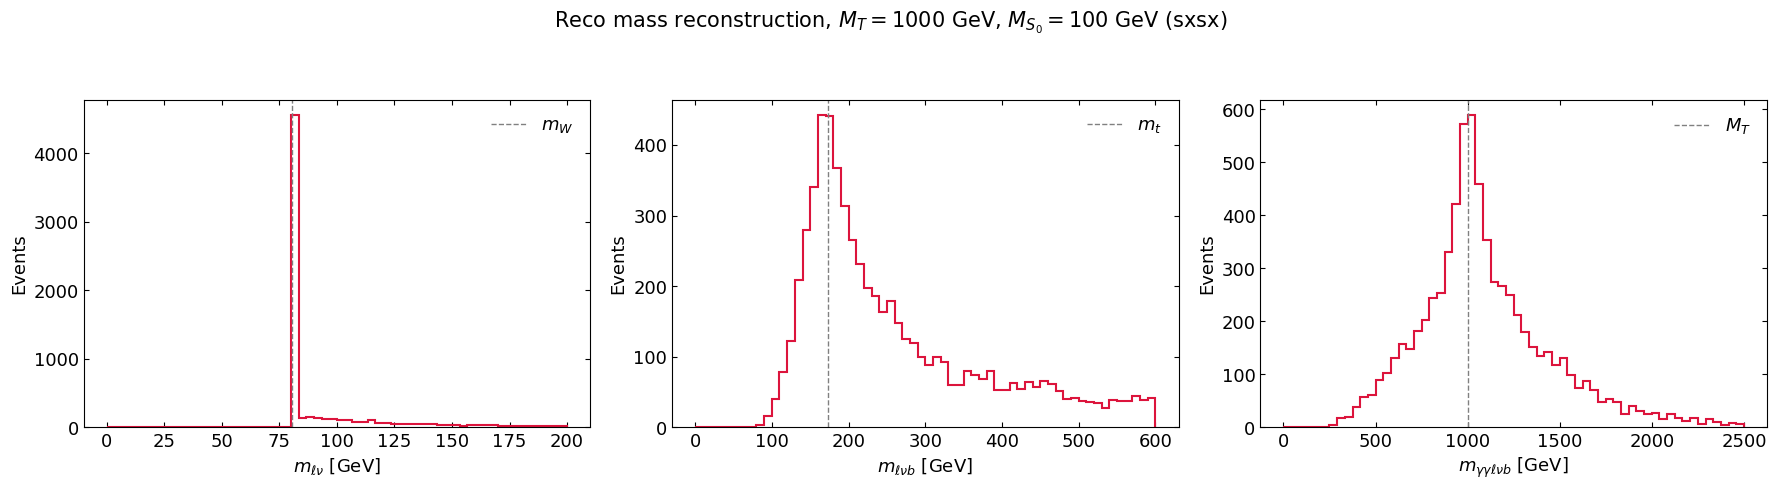

m_W reco: mean=116.3, median=80.4 GeV
m_top reco: mean=361.4, median=241.2 GeV
m_T reco: mean=1107.1, median=1036.4 GeV


/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [53]:
# reco neutrino 4-vector
nu_px_r = ak.to_numpy(met_px)
nu_py_r = ak.to_numpy(met_py)

# reco W mass check
m_W_reco = np.sqrt(np.maximum((lep_E + nu_E)**2 - (lep_px + nu_px_r)**2 - (lep_py + nu_py_r)**2 - (lep_pz + nu_pz)**2, 0))

# reco top mass
b_E = np.sqrt(ak.to_numpy(px(b_lep_reco))**2 + ak.to_numpy(py(b_lep_reco))**2 + ak.to_numpy(pz(b_lep_reco))**2 + ak.to_numpy(b_lep_reco.mass)**2)
m_top_reco = np.sqrt(np.maximum((ak.to_numpy(lep_E) + nu_E + b_E)**2 - (ak.to_numpy(lep_px) + nu_px_r + ak.to_numpy(px(b_lep_reco)))**2 - (ak.to_numpy(lep_py) + nu_py_r + ak.to_numpy(py(b_lep_reco)))**2 - (ak.to_numpy(lep_pz) + nu_pz + ak.to_numpy(pz(b_lep_reco)))**2, 0))

# best photon pair for T mass (reuse best_mgg logic but keep the photon 4-vectors)
g1_pt = np.zeros(len(pho_r))
g1_eta = np.zeros(len(pho_r))
g1_phi = np.zeros(len(pho_r))
g1_mass = np.zeros(len(pho_r))
g2_pt = np.zeros(len(pho_r))
g2_eta = np.zeros(len(pho_r))
g2_phi = np.zeros(len(pho_r))
g2_mass = np.zeros(len(pho_r))
n_pho_r = ak.num(pho_r)

for i in range(len(pho_r)):
    npho = n_pho_r[i]
    if npho < 2:
        continue
    phos = pho_r[i]
    best_diff = 9999
    for a in range(npho):
        for b in range(a+1, npho):
            m = float(inv_mass(phos[a:a+1], phos[b:b+1])[0])
            if abs(m - 100) < best_diff:
                best_diff = abs(m - 100)
                g1_pt[i], g1_eta[i], g1_phi[i], g1_mass[i] = phos[a].pt, phos[a].eta, phos[a].phi, phos[a].mass
                g2_pt[i], g2_eta[i], g2_phi[i], g2_mass[i] = phos[b].pt, phos[b].eta, phos[b].phi, phos[b].mass

g1_px = g1_pt * np.cos(g1_phi)
g1_py = g1_pt * np.sin(g1_phi)
g1_pz = g1_pt * np.sinh(g1_eta)
g1_E = np.sqrt(g1_px**2 + g1_py**2 + g1_pz**2 + g1_mass**2)
g2_px = g2_pt * np.cos(g2_phi)
g2_py = g2_pt * np.sin(g2_phi)
g2_pz = g2_pt * np.sinh(g2_eta)
g2_E = np.sqrt(g2_px**2 + g2_py**2 + g2_pz**2 + g2_mass**2)

tot_px = ak.to_numpy(lep_px) + nu_px_r + ak.to_numpy(px(b_lep_reco)) + g1_px + g2_px
tot_py = ak.to_numpy(lep_py) + nu_py_r + ak.to_numpy(py(b_lep_reco)) + g1_py + g2_py
tot_pz = ak.to_numpy(lep_pz) + nu_pz + ak.to_numpy(pz(b_lep_reco)) + g1_pz + g2_pz
tot_E = ak.to_numpy(lep_E) + nu_E + b_E + g1_E + g2_E
m_T_reco = np.sqrt(np.maximum(tot_E**2 - tot_px**2 - tot_py**2 - tot_pz**2, 0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r'Reco mass reconstruction, $M_T = 1000$ GeV, $M_{S_0} = 100$ GeV (sxsx)', fontsize=15)

axes[0].hist(m_W_reco, bins=60, range=(0, 200), histtype='step', color='crimson', linewidth=1.5)
axes[0].axvline(80.4, color='gray', linestyle='--', linewidth=1, label=r'$m_W$')
axes[0].set_xlabel(r'$m_{\ell\nu}$ [GeV]')
axes[0].set_ylabel('Events')
axes[0].legend(frameon=False)

axes[1].hist(m_top_reco, bins=60, range=(0, 600), histtype='step', color='crimson', linewidth=1.5)
axes[1].axvline(173, color='gray', linestyle='--', linewidth=1, label=r'$m_t$')
axes[1].set_xlabel(r'$m_{\ell\nu b}$ [GeV]')
axes[1].set_ylabel('Events')
axes[1].legend(frameon=False)

axes[2].hist(m_T_reco, bins=60, range=(0, 2500), histtype='step', color='crimson', linewidth=1.5)
axes[2].axvline(1000, color='gray', linestyle='--', linewidth=1, label=r'$M_T$')
axes[2].set_xlabel(r'$m_{\gamma\gamma\ell\nu b}$ [GeV]')
axes[2].set_ylabel('Events')
axes[2].legend(frameon=False)

for a in axes:
    a.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('reco_mass_1000_100_sxsx.pdf', bbox_inches='tight')
plt.show()

print(f'm_W reco: mean={np.mean(m_W_reco):.1f}, median={np.median(m_W_reco):.1f} GeV')
print(f'm_top reco: mean={np.mean(m_top_reco):.1f}, median={np.median(m_top_reco):.1f} GeV')
print(f'm_T reco: mean={np.mean(m_T_reco):.1f}, median={np.median(m_T_reco):.1f} GeV')

## Neutrino discriminant distributions
Check the W mass constraint discriminant sign and reco mass distributions split by positive vs negative discriminant.

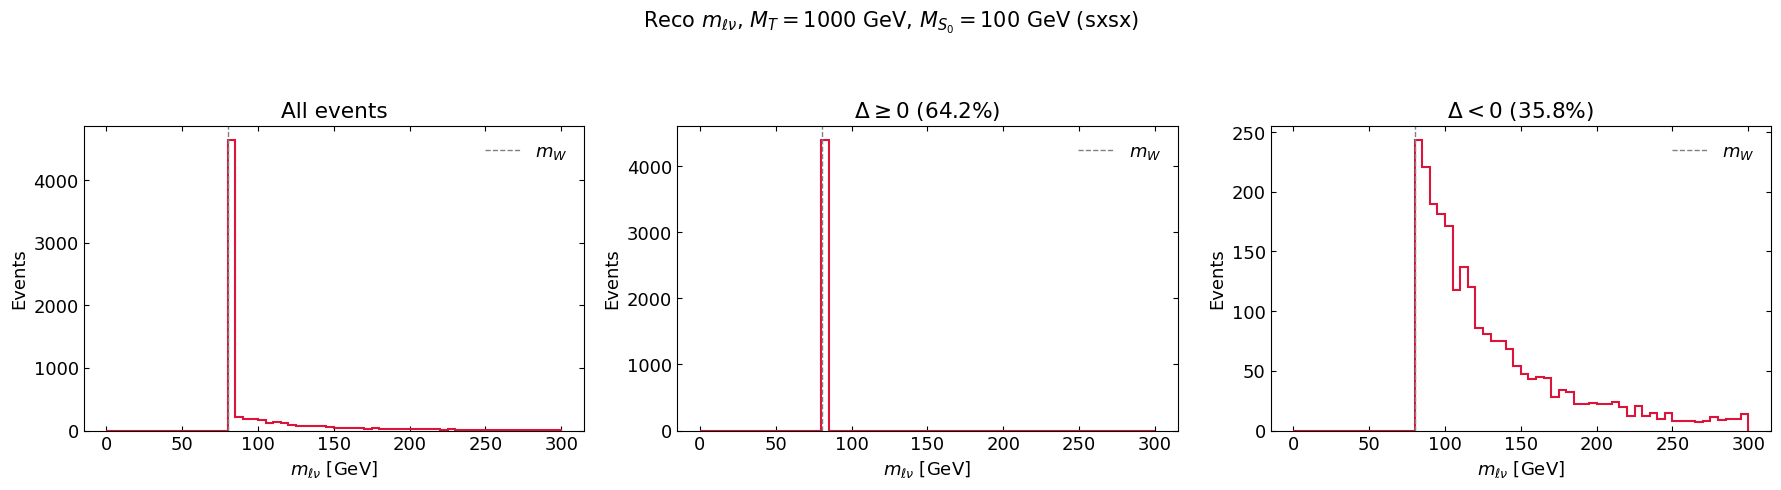

All: mean=116.3, median=80.4 GeV
D>=0: mean=80.4, median=80.4 GeV
D<0: mean=174.1, median=119.0 GeV


In [54]:
disc_pos = disc_np >= 0
disc_neg = disc_np < 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r'Reco $m_{\ell\nu}$, $M_T = 1000$ GeV, $M_{S_0} = 100$ GeV (sxsx)', fontsize=15)

axes[0].hist(m_W_reco, bins=60, range=(0, 300), histtype='step', color='crimson', linewidth=1.5)
axes[0].axvline(80.4, color='gray', linestyle='--', linewidth=1, label=r'$m_W$')
axes[0].set_xlabel(r'$m_{\ell\nu}$ [GeV]')
axes[0].set_ylabel('Events')
axes[0].set_title('All events')
axes[0].legend(frameon=False)

axes[1].hist(m_W_reco[disc_pos], bins=60, range=(0, 300), histtype='step', color='crimson', linewidth=1.5)
axes[1].axvline(80.4, color='gray', linestyle='--', linewidth=1, label=r'$m_W$')
axes[1].set_xlabel(r'$m_{\ell\nu}$ [GeV]')
axes[1].set_ylabel('Events')
axes[1].set_title(r'$\Delta \geq 0$ (64.2%)')
axes[1].legend(frameon=False)

axes[2].hist(m_W_reco[disc_neg], bins=60, range=(0, 300), histtype='step', color='crimson', linewidth=1.5)
axes[2].axvline(80.4, color='gray', linestyle='--', linewidth=1, label=r'$m_W$')
axes[2].set_xlabel(r'$m_{\ell\nu}$ [GeV]')
axes[2].set_ylabel('Events')
axes[2].set_title(r'$\Delta < 0$ (35.8%)')
axes[2].legend(frameon=False)

for a in axes:
    a.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('mW_reco_split_1000_100_sxsx.pdf', bbox_inches='tight')
plt.show()

print(f'All: mean={np.mean(m_W_reco):.1f}, median={np.median(m_W_reco):.1f} GeV')
print(f'D>=0: mean={np.mean(m_W_reco[disc_pos]):.1f}, median={np.median(m_W_reco[disc_pos]):.1f} GeV')
print(f'D<0: mean={np.mean(m_W_reco[disc_neg]):.1f}, median={np.median(m_W_reco[disc_neg]):.1f} GeV')

## Chi2-based b-jet and neutrino selection
Scan all b-jets and neutrino pz solutions, pick the combination minimizing chi2 = ((m_top - 173)/30)^2. Compare to the dR-based assignment.

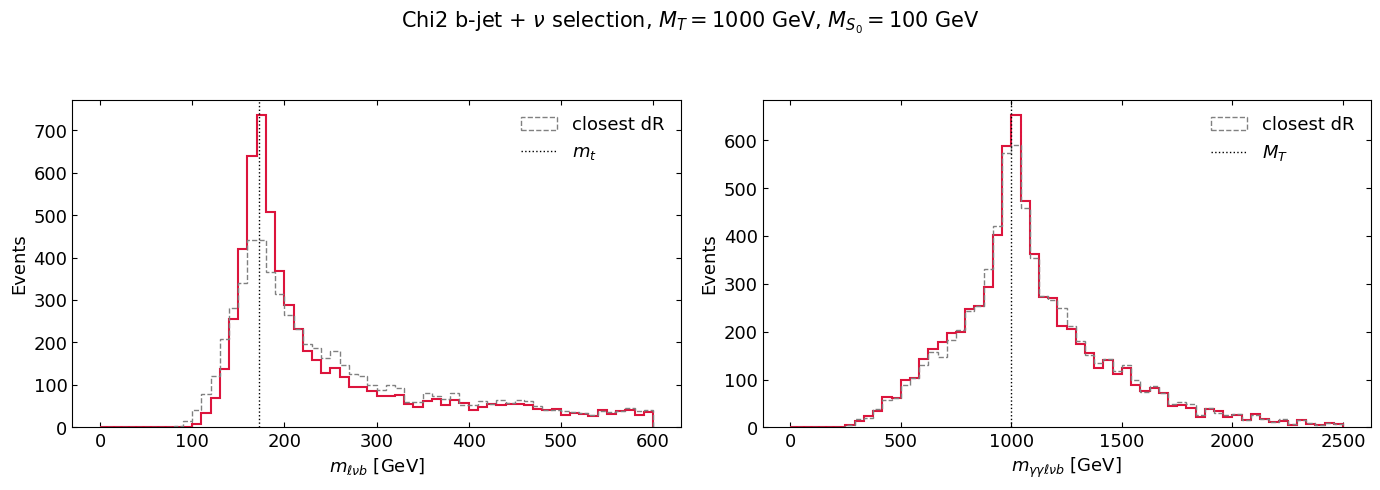

Chi2 m_top: mean=341.6, median=213.8 GeV
Chi2 m_T: mean=1094.5, median=1030.7 GeV
dR m_top: mean=361.4, median=241.2 GeV
dR m_T: mean=1107.1, median=1036.4 GeV


/cvmfs/cms.cern.ch/el9_amd64_gcc11/external/py3-numpy/1.22.4-1e1240160543ee39175a125e9a5e9cae/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [55]:
n_bjet = ak.num(bjet_r)
met_np = ak.to_numpy(met_rsel)
metphi_np = ak.to_numpy(metphi_rsel)
lep_px_np = ak.to_numpy(lep_px)
lep_py_np = ak.to_numpy(lep_py)
lep_pz_np = ak.to_numpy(lep_pz)
lep_E_np = ak.to_numpy(lep_E)
met_px_np = ak.to_numpy(met_px)
met_py_np = ak.to_numpy(met_py)

MW = 80.4
MT_TOP = 173.0

chi2_best_mtop = np.full(len(bjet_r), -1.0)
chi2_best_mT = np.full(len(bjet_r), -1.0)
chi2_best_nupz = np.full(len(bjet_r), 0.0)

for i in range(len(bjet_r)):
    nb = n_bjet[i]
    if nb < 1:
        continue

    mu_i = MW**2 / 2 + lep_px_np[i] * met_px_np[i] + lep_py_np[i] * met_py_np[i]
    A_i = lep_E_np[i]**2 - lep_pz_np[i]**2
    B_i = -2 * mu_i * lep_pz_np[i]
    C_i = lep_E_np[i]**2 * met_np[i]**2 - mu_i**2
    D_i = B_i**2 - 4*A_i*C_i

    if D_i >= 0:
        sd = np.sqrt(D_i)
        nu_sols = [(-B_i + sd)/(2*A_i), (-B_i - sd)/(2*A_i)]
    else:
        nu_sols = [-B_i/(2*A_i)]

    best_chi2 = 9999
    best_mt = -1
    best_mT_val = -1
    best_nupz = 0

    for nu_pz_i in nu_sols:
        nu_E_i = np.sqrt(met_np[i]**2 + nu_pz_i**2)
        for j in range(nb):
            bj = bjet_r[i][j]
            b_px_j = float(bj.pt * np.cos(bj.phi))
            b_py_j = float(bj.pt * np.sin(bj.phi))
            b_pz_j = float(bj.pt * np.sinh(bj.eta))
            b_E_j = np.sqrt(b_px_j**2 + b_py_j**2 + b_pz_j**2 + float(bj.mass)**2)

            tot_E = lep_E_np[i] + nu_E_i + b_E_j
            tot_px = lep_px_np[i] + met_px_np[i] + b_px_j
            tot_py = lep_py_np[i] + met_py_np[i] + b_py_j
            tot_pz = lep_pz_np[i] + nu_pz_i + b_pz_j
            mt = np.sqrt(max(tot_E**2 - tot_px**2 - tot_py**2 - tot_pz**2, 0))

            chi2_val = ((mt - MT_TOP) / 30.0)**2
            if chi2_val < best_chi2:
                best_chi2 = chi2_val
                best_mt = mt
                best_nupz = nu_pz_i

                g1_i, g2_i = best_idx_a[i], best_idx_b[i]
                pho_i = pho_r[i]
                g1p = pho_i[g1_i]
                g2p = pho_i[g2_i]
                g1_px_i = float(g1p.pt * np.cos(g1p.phi))
                g1_py_i = float(g1p.pt * np.sin(g1p.phi))
                g1_pz_i = float(g1p.pt * np.sinh(g1p.eta))
                g1_E_i = np.sqrt(g1_px_i**2 + g1_py_i**2 + g1_pz_i**2 + float(g1p.mass)**2)
                g2_px_i = float(g2p.pt * np.cos(g2p.phi))
                g2_py_i = float(g2p.pt * np.sin(g2p.phi))
                g2_pz_i = float(g2p.pt * np.sinh(g2p.eta))
                g2_E_i = np.sqrt(g2_px_i**2 + g2_py_i**2 + g2_pz_i**2 + float(g2p.mass)**2)

                T_E = tot_E + g1_E_i + g2_E_i
                T_px = tot_px + g1_px_i + g2_px_i
                T_py = tot_py + g1_py_i + g2_py_i
                T_pz = tot_pz + g1_pz_i + g2_pz_i
                best_mT_val = np.sqrt(max(T_E**2 - T_px**2 - T_py**2 - T_pz**2, 0))

    chi2_best_mtop[i] = best_mt
    chi2_best_mT[i] = best_mT_val
    chi2_best_nupz[i] = best_nupz

valid_chi2 = chi2_best_mtop > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(r'Chi2 b-jet + $\nu$ selection, $M_T = 1000$ GeV, $M_{S_0} = 100$ GeV', fontsize=15)

axes[0].hist(chi2_best_mtop[valid_chi2], bins=60, range=(0, 600),
    histtype='step', color='crimson', linewidth=1.5)
axes[0].hist(m_top_reco, bins=60, range=(0, 600),
    histtype='step', color='gray', linewidth=1, linestyle='--', label='closest dR')
axes[0].axvline(173, color='black', linestyle=':', linewidth=1, label=r'$m_t$')
axes[0].set_xlabel(r'$m_{\ell\nu b}$ [GeV]')
axes[0].set_ylabel('Events')
axes[0].legend(frameon=False)

axes[1].hist(chi2_best_mT[valid_chi2], bins=60, range=(0, 2500),
    histtype='step', color='crimson', linewidth=1.5)
axes[1].hist(m_T_reco, bins=60, range=(0, 2500),
    histtype='step', color='gray', linewidth=1, linestyle='--', label='closest dR')
axes[1].axvline(1000, color='black', linestyle=':', linewidth=1, label=r'$M_T$')
axes[1].set_xlabel(r'$m_{\gamma\gamma\ell\nu b}$ [GeV]')
axes[1].set_ylabel('Events')
axes[1].legend(frameon=False)

for a in axes:
    a.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('chi2_vs_dR_1000_100_sxsx.pdf', bbox_inches='tight')
plt.show()

print(f'Chi2 m_top: mean={np.mean(chi2_best_mtop[valid_chi2]):.1f}, median={np.median(chi2_best_mtop[valid_chi2]):.1f} GeV')
print(f'Chi2 m_T: mean={np.mean(chi2_best_mT[valid_chi2]):.1f}, median={np.median(chi2_best_mT[valid_chi2]):.1f} GeV')
print(f'dR m_top: mean={np.mean(m_top_reco):.1f}, median={np.median(m_top_reco):.1f} GeV')
print(f'dR m_T: mean={np.mean(m_T_reco):.1f}, median={np.median(m_T_reco):.1f} GeV')

## Load Run 3 background samples
Load TTGG (13.6 TeV, 1.39M total) and TTG-1Jets (13.6 TeV) from central NanoAODv12 via xrootd.

In [57]:
xrd = "root://cmsxrootd.fnal.gov/"

files_ttgg = [
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTGG_TuneCP5_13p6TeV_madgraph-madspin-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/31388478-0f2b-4d1a-8dd9-d516166b521d.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTGG_TuneCP5_13p6TeV_madgraph-madspin-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/a7108eff-473e-4574-b5df-c82a26b94682.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTGG_TuneCP5_13p6TeV_madgraph-madspin-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/4609767e-98f4-4ca8-af8e-3e035020e085.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTGG_TuneCP5_13p6TeV_madgraph-madspin-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/ef144582-3bae-4254-a240-6b4f15d282bf.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTGG_TuneCP5_13p6TeV_madgraph-madspin-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/ec303fb2-64d6-4159-8ce8-59bc31432e79.root",
]

files_ttg1j = [
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2560000/f2bbf315-4cdf-4cdc-ac48-b326d7f2fc01.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2560000/cbf32dee-3bbd-417d-aad8-59ae2c41ca27.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2560000/62e7d458-3036-41d8-a49b-ecdb305dbd20.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2560000/340a3f05-e8aa-4fba-ac91-34e708503489.root",
    xrd + "/store/mc/Run3Summer23NanoAODv12/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2560000/3cbcb551-68b2-4dc7-8948-ee914549843e.root",
]

reco_branches_bkg = [b for b in reco_branches if b != 'Photon_mass']

print("Loading Run 3 TTGG...")
ev_ttgg = uproot.concatenate({f: 'Events' for f in files_ttgg}, reco_branches_bkg, library='ak')
print(f'TTGG: {len(ev_ttgg)} events loaded')

print("Loading Run 3 TTG-1Jets...")
chunks = []
for i, f in enumerate(files_ttg1j):
    try:
        ch = uproot.concatenate({f: 'Events'}, reco_branches_bkg, library='ak')
        chunks.append(ch)
        print(f'  File {i}: {len(ch)} events')
    except Exception as e:
        print(f'  File {i}: FAILED ({e})')
ev_ttg1j = ak.concatenate(chunks)
print(f'TTG-1Jets: {len(ev_ttg1j)} events loaded')

Loading Run 3 TTGG...
TTGG: 72000 events loaded
Loading Run 3 TTG-1Jets...
  File 0: 245266 events
  File 1: 264281 events
  File 2: 248606 events
  File 3: 241206 events
  File 4: 239004 events
TTG-1Jets: 1238363 events loaded


## Run reco selection on backgrounds
Apply the same reco cuts to TTGG and TTGJets. Compute HT, ST, and mgg (leading-pT pair) for shape comparison with signal.

In [59]:
def run_selection(ev, label):
    ele = ak.zip({'pt': ev['Electron_pt'], 'eta': ev['Electron_eta'],
        'phi': ev['Electron_phi'], 'mass': ev['Electron_mass'],
        'cutBased': ev['Electron_cutBased'],
        'mvaWP80': ev['Electron_mvaIso_WP80'],
        'dEtaSC': ev['Electron_deltaEtaSC'], 'dz': ev['Electron_dz'],
        'ip3d': ev['Electron_ip3d']})
    mu = ak.zip({'pt': ev['Muon_pt'], 'eta': ev['Muon_eta'],
        'phi': ev['Muon_phi'], 'mass': ev['Muon_mass'],
        'tightId': ev['Muon_tightId'], 'dz': ev['Muon_dz'],
        'dxy': ev['Muon_dxy']})
    jets = ak.zip({'pt': ev['Jet_pt'], 'eta': ev['Jet_eta'],
        'phi': ev['Jet_phi'], 'mass': ev['Jet_mass'],
        'btag': ev['Jet_btagDeepFlavB'], 'jetId': ev['Jet_jetId']})
    pho = ak.zip({'pt': ev['Photon_pt'], 'eta': ev['Photon_eta'],
        'phi': ev['Photon_phi'], 'mass': 0.0,
        'cutBased': ev['Photon_cutBased'], 'pixelSeed': ev['Photon_pixelSeed']})

    sc_eta = abs(ele.eta + ele.dEtaSC)
    barrel = sc_eta < 1.4442
    endcap = sc_eta > 1.566
    ele_s = ele[(ele.pt > 30) & (abs(ele.eta) < 2.4) & (barrel | endcap) &
        (ele.cutBased >= 3) & (ele.mvaWP80) &
        ak.where(barrel, (abs(ele.dz) < 0.10) & (ele.ip3d < 0.05),
                          (abs(ele.dz) < 0.20) & (ele.ip3d < 0.10))]
    mu_s = mu[(mu.pt > 30) & (abs(mu.eta) < 2.4) & mu.tightId &
        (abs(mu.dz) < 0.05) & (abs(mu.dxy) < 0.02)]

    lep = ak.concatenate([ele_s, mu_s], axis=1)
    lep = lep[ak.argsort(lep.pt, ascending=False)]

    jet_s = jets[(jets.pt > 30) & (abs(jets.eta) < 2.4) & (jets.jetId >= 2)]
    pair_dR = dR_calc(jet_s.eta[:, :, None], jet_s.phi[:, :, None],
                      lep.eta[:, None, :], lep.phi[:, None, :])
    min_dR = ak.min(pair_dR, axis=2)
    jet_c = jet_s[ak.fill_none(min_dR, 999) > 0.4]
    bjet = jet_c[jet_c.btag > 0.2431]  # DeepJet medium WP 2023

    pho_s = pho[(pho.pt > 20) & (abs(pho.eta) < 2.5) &
        (pho.cutBased >= 2) & (~pho.pixelSeed)]

    sel = (ak.num(lep) == 1) & (ak.num(bjet) >= 1) & (ak.num(pho_s) >= 2)
    n_pass = int(ak.sum(sel))
    print(f'{label}: {n_pass} / {len(ev)} pass ({n_pass/len(ev):.4%})')

    jet_sel = jet_c[sel]
    lep_sel = lep[sel][:, 0]
    pho_sel_out = pho_s[sel]
    met_sel = ev['MET_pt'][sel]

    ht = ak.sum(jet_sel.pt, axis=1)
    st = ht + lep_sel.pt + met_sel

    # best mgg
    n_pho = ak.num(pho_sel_out)
    mgg_arr = np.full(n_pass, -1.0)
    for i in range(n_pass):
        npho = n_pho[i]
        if npho < 2:
            continue
        phos = pho_sel_out[i]
        best_diff = 9999
        for a in range(npho):
            for b in range(a+1, npho):
                m = float(inv_mass(phos[a:a+1], phos[b:b+1])[0])
                if abs(m - 100) < best_diff:
                    best_diff = abs(m - 100)
                    mgg_arr[i] = m

    return {'ht': ak.to_numpy(ht), 'st': ak.to_numpy(st), 'mgg': mgg_arr,
            'met': ak.to_numpy(met_sel), 'n_pass': n_pass}

print("Running selection...")
res_ttgg = run_selection(ev_ttgg, "TTGG")
res_ttg1j = run_selection(ev_ttg1j, "TTG-1Jets")

Running selection...
TTGG: 1306 / 72000 pass (1.8139%)
TTG-1Jets: 852 / 1238363 pass (0.0688%)


## Signal vs background shape comparison (normalized to unity)
Overlay signal and background distributions of HT, ST, and mgg to check shape discrimination.

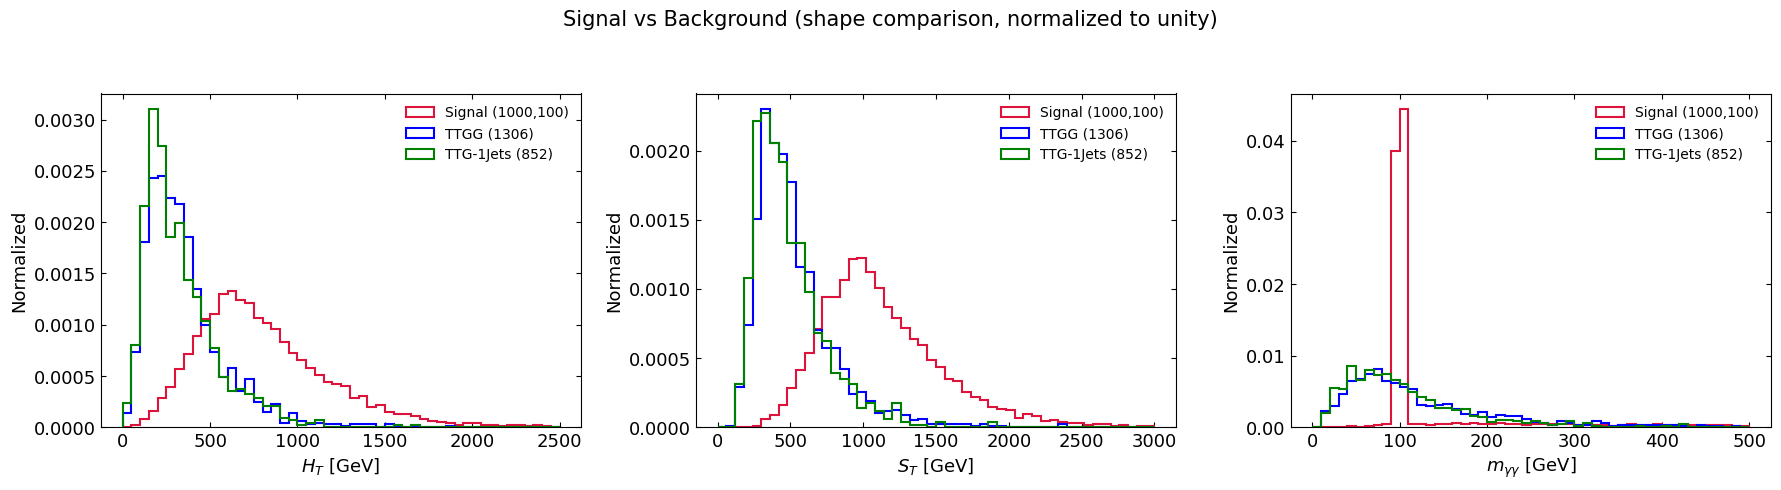

Signal mgg median: 100.3 GeV
TTGG mgg median: 98.6 GeV
TTG-1Jets mgg median: 89.4 GeV


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Signal vs Background (shape comparison, normalized to unity)', fontsize=15)

# signal HT/ST/mgg from earlier
sig_ht = ak.to_numpy(HT)
sig_st = ak.to_numpy(ST)
sig_mgg = mgg_reco[mgg_reco > 0]

for ax, var_sig, var_ttgg, var_ttgj, xlabel, xrange in [
    (axes[0], sig_ht, res_ttgg['ht'], res_ttg1j['ht'], r'$H_T$ [GeV]', (0, 2500)),
    (axes[1], sig_st, res_ttgg['st'], res_ttg1j['st'], r'$S_T$ [GeV]', (0, 3000)),
    (axes[2], sig_mgg, res_ttgg['mgg'][res_ttgg['mgg'] > 0],
              res_ttg1j['mgg'][res_ttg1j['mgg'] > 0], r'$m_{\gamma\gamma}$ [GeV]', (0, 500)),
]:
    ax.hist(var_sig, bins=50, range=xrange, histtype='step', color='crimson',
        linewidth=1.5, density=True, label=f'Signal (1000,100)')
    ax.hist(var_ttgg, bins=50, range=xrange, histtype='step', color='blue',
        linewidth=1.5, density=True, label=f'TTGG ({res_ttgg["n_pass"]})')
    if len(var_ttgj) > 10:
        ax.hist(var_ttgj, bins=50, range=xrange, histtype='step', color='green',
            linewidth=1.5, density=True, label=f'TTG-1Jets ({res_ttg1j["n_pass"]})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Normalized')
    ax.legend(frameon=False, fontsize=10)
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('sig_vs_bkg_1000_100_sxsx.pdf', bbox_inches='tight')
plt.show()

print(f'Signal mgg median: {np.median(sig_mgg):.1f} GeV')
print(f'TTGG mgg median: {np.median(res_ttgg["mgg"][res_ttgg["mgg"] > 0]):.1f} GeV')
if np.sum(res_ttg1j['mgg'] > 0) > 0:
    print(f'TTG-1Jets mgg median: {np.median(res_ttg1j["mgg"][res_ttg1j["mgg"] > 0]):.1f} GeV')

## Leading-pair mgg comparison
Compare mgg from the two highest-pT photons across signal and backgrounds.

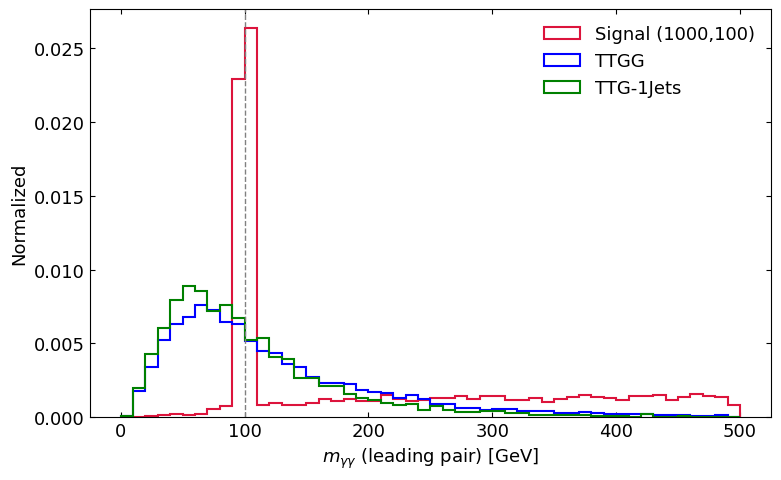

Signal leading mgg median: 302.5 GeV
TTGG leading mgg median: 99.2 GeV
TTG-1Jets leading mgg median: 86.7 GeV


In [62]:
def get_leading_mgg(ev):
    pho = ak.zip({'pt': ev['Photon_pt'], 'eta': ev['Photon_eta'],
        'phi': ev['Photon_phi'], 'mass': 0.0,
        'cutBased': ev['Photon_cutBased'], 'pixelSeed': ev['Photon_pixelSeed']})
    pho_s = pho[(pho.pt > 20) & (abs(pho.eta) < 2.5) &
        (pho.cutBased >= 2) & (~pho.pixelSeed)]
    has2 = ak.num(pho_s) >= 2
    return ak.to_numpy(inv_mass(pho_s[has2][:, 0], pho_s[has2][:, 1]))

mgg_ttgg_lead = get_leading_mgg(ev_ttgg)
mgg_ttg1j_lead = get_leading_mgg(ev_ttg1j)
sig_mgg_lead = ak.to_numpy(mgg)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sig_mgg_lead, bins=50, range=(0, 500), histtype='step', color='crimson',
    linewidth=1.5, density=True, label='Signal (1000,100)')
ax.hist(mgg_ttgg_lead, bins=50, range=(0, 500), histtype='step', color='blue',
    linewidth=1.5, density=True, label='TTGG')
ax.hist(mgg_ttg1j_lead, bins=50, range=(0, 500), histtype='step', color='green',
    linewidth=1.5, density=True, label='TTG-1Jets')
ax.axvline(100, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel(r'$m_{\gamma\gamma}$ (leading pair) [GeV]')
ax.set_ylabel('Normalized')
ax.legend(frameon=False)
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

print(f'Signal leading mgg median: {np.median(sig_mgg_lead):.1f} GeV')
print(f'TTGG leading mgg median: {np.median(mgg_ttgg_lead):.1f} GeV')
print(f'TTG-1Jets leading mgg median: {np.median(mgg_ttg1j_lead):.1f} GeV')

## Luminosity-weighted signal vs background
Weight events to 27 fb-1 (Run 3 2023) using theory cross sections at 13.6 TeV.

Run 3 2023, L = 27.0 fb^-1
Weight per event:
  Signal: 0.009787
  TTGG: 0.000330
  TTG-1Jets: 0.025312

Expected yields (27.0 fb^-1):
  Signal: 69.7
  TTGG: 0.4
  TTG-1Jets: 21.6


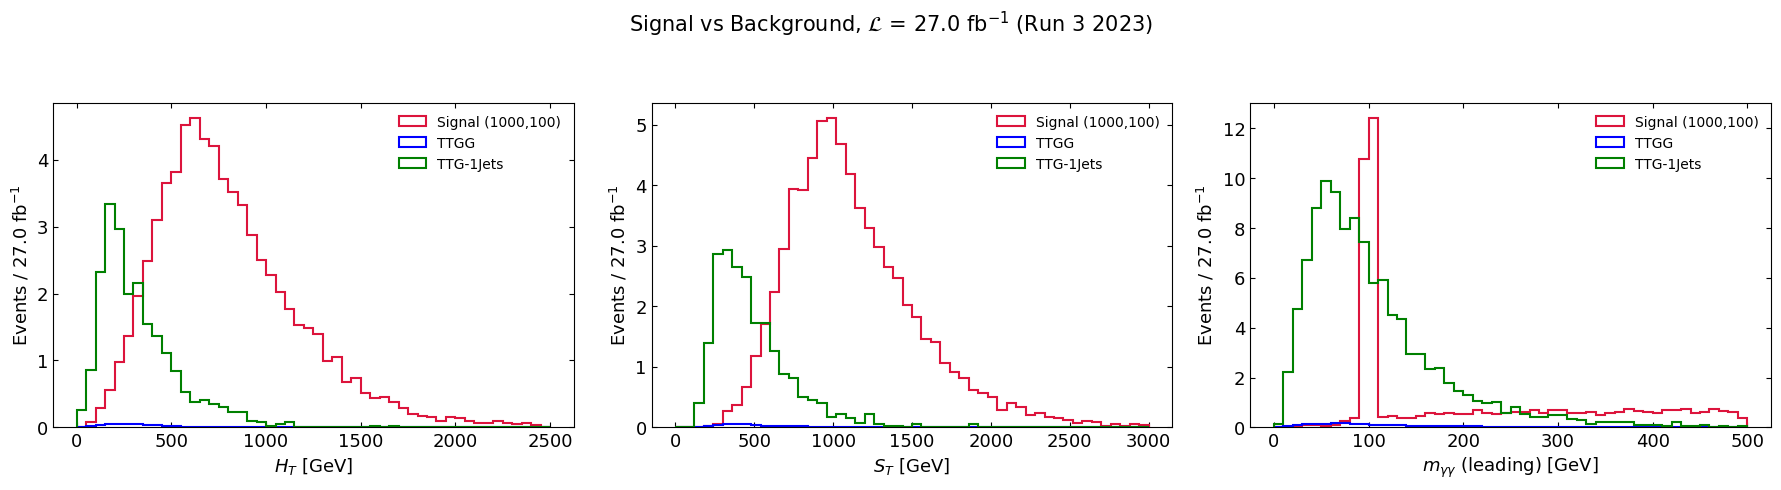

In [63]:
def get_leading_mgg(ev):
    pho = ak.zip({'pt': ev['Photon_pt'], 'eta': ev['Photon_eta'],
        'phi': ev['Photon_phi'], 'mass': 0.0,
        'cutBased': ev['Photon_cutBased'], 'pixelSeed': ev['Photon_pixelSeed']})
    pho_s = pho[(pho.pt > 20) & (abs(pho.eta) < 2.5) &
        (pho.cutBased >= 2) & (~pho.pixelSeed)]
    has2 = ak.num(pho_s) >= 2
    return ak.to_numpy(inv_mass(pho_s[has2][:, 0], pho_s[has2][:, 1]))

mgg_ttgg_lead = get_leading_mgg(ev_ttgg)
mgg_ttg1j_lead = get_leading_mgg(ev_ttg1j)
sig_mgg_lead = ak.to_numpy(mgg)

# Run 3 2023 luminosity
LUMI = 27.0  # fb^-1, Run 3 2023 (approximate)

# signal: theory xsec at 13.6 TeV, MT=1000
xsec_sig = 0.029  # pb, TT pair at MT=1000 (13.6 TeV, from gridpack validation)
br_aa = 0.25
n_sig_total = len(events)
w_sig = (LUMI * 1000 * xsec_sig * br_aa) / n_sig_total

# TTGG 13.6 TeV: xsec ~ 0.017 pb (check genXSecAnalyzer), 1.39M total events
n_ttgg_total = 1391000
w_ttgg = (LUMI * 1000 * 0.017) / n_ttgg_total

# TTG-1Jets 13.6 TeV: xsec ~ 4.0 pb (check genXSecAnalyzer), total events from DAS
n_ttg1j_total = 4266819
w_ttg1j = (LUMI * 1000 * 4.0) / n_ttg1j_total

print(f'Run 3 2023, L = {LUMI} fb^-1')
print(f'Weight per event:')
print(f'  Signal: {w_sig:.6f}')
print(f'  TTGG: {w_ttgg:.6f}')
print(f'  TTG-1Jets: {w_ttg1j:.6f}')

n_sig_sel = int(ak.sum(reco_sel))
print(f'\nExpected yields ({LUMI} fb^-1):')
print(f'  Signal: {n_sig_sel * w_sig:.1f}')
print(f'  TTGG: {res_ttgg["n_pass"] * w_ttgg:.1f}')
print(f'  TTG-1Jets: {res_ttg1j["n_pass"] * w_ttg1j:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(r'Signal vs Background, $\mathcal{L}$ = ' + f'{LUMI}' + r' fb$^{-1}$ (Run 3 2023)', fontsize=15)

for ax, var_sig, var_ttgg, var_ttg1j, xlabel, xrange in [
    (axes[0], sig_ht, res_ttgg['ht'], res_ttg1j['ht'], r'$H_T$ [GeV]', (0, 2500)),
    (axes[1], sig_st, res_ttgg['st'], res_ttg1j['st'], r'$S_T$ [GeV]', (0, 3000)),
    (axes[2], sig_mgg_lead, mgg_ttgg_lead, mgg_ttg1j_lead, r'$m_{\gamma\gamma}$ (leading) [GeV]', (0, 500)),
]:
    ax.hist(var_sig, bins=50, range=xrange, histtype='step', color='crimson',
        linewidth=1.5, weights=np.full(len(var_sig), w_sig), label='Signal (1000,100)')
    ax.hist(var_ttgg, bins=50, range=xrange, histtype='step', color='blue',
        linewidth=1.5, weights=np.full(len(var_ttgg), w_ttgg), label='TTGG')
    ax.hist(var_ttg1j, bins=50, range=xrange, histtype='step', color='green',
        linewidth=1.5, weights=np.full(len(var_ttg1j), w_ttg1j), label='TTG-1Jets')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Events / ' + f'{LUMI}' + r' fb$^{-1}$')
    ax.legend(frameon=False, fontsize=10)
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('sig_vs_bkg_weighted_1000_100_run3.pdf', bbox_inches='tight')
plt.show()
